# Lab 0 · Climb the ladder: from counting to attention, one loss the whole way

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leippold/finance-nlp-workshop/blob/main/colabs/00_climb_the_ladder.ipynb)

**75-minute graduate lab for Sessions 1–2.** Every model in this notebook
estimates the same object — $p(x_t \mid x_{<t})$ — reads it out through one
softmax head, and is scored by one number, held-out **bits per character**.
Only the *encoder* changes rung to rung. You will watch the count table hit
Zipf's wall, verify the gradient $\partial\ell/\partial z = p - e_y$ that
trains every rung above it, and then open a *trained* GPT-2 and measure the
induction bump that Session 1 only drew.

| Route | Time | What you build |
|---|---:|---|
| **Core · the ladder** | 40 min | char $n$-grams, the wall, interpolation, $p-e_y$ verified, neural rungs |
| **Deep · induction** | 20 min | the in-context bump in GPT-2, and the heads that produce it |
| **Stretch · corpus & scaling** | 15 min | fetch a real 10-K, rerun the ladder, fit a mini scaling law |

> **The corpus is deliberately part of the lesson.** The frozen fallback is
> ~4,000 characters of real Microsoft 10-K text — far too small, and the
> notebook will show you *exactly how* too small: the wall arrives at $n=2$
> instead of $n=4$. The stretch path fetches one full filing (~10^5 chars)
> and the same code tells a different story. Data, not architecture, moves
> the numbers — which is Session 2's opening claim.

## 1. Setup, corpus, and the one evaluation axis

All rungs are judged on the same axis: mean $-\log_2 p(x_t \mid x_{<t})$ on
characters the model never saw, in **bits per character**. Session 1 proved
the floor: no model beats the entropy rate of the source.

The split is **by document**, never by character — a random character split
would leak each document's style into training, the small-scale version of
the leakage Session 4 makes structural.

In [1]:
import math, random, re
from pathlib import Path
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value): print(value)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'blue': '#22577D', 'blue_light': '#5E92B5', 'gold': '#B5862E',
    'gold_light': '#E4D3A6', 'ink': '#1B1915', 'slate': '#6C6457',
    'grid': '#D9D0C0', 'open': '#FBF8F1',
}
RUN_HUGGINGFACE = False   #@param {type:"boolean"}
REFRESH_FROM_SEC = False  #@param {type:"boolean"}
RUN_SCALING = False       #@param {type:"boolean"}
try:
    import torch
    TORCH_OK = True
    torch.manual_seed(0)
except ImportError:
    TORCH_OK = False
    print('PyTorch not installed: the neural rungs will be skipped. '
          'Colab supplies it; locally `pip install torch`.')

rng = np.random.default_rng(0)

def load_teaching_csv(filename, **read_csv_kwargs):
    # Use a checkout when present; otherwise prompt for a Colab upload.
    candidates = [
        Path('../teaching-data') / filename,
        Path('teaching-data') / filename,
        Path('/content') / filename,
        Path(filename),
    ]
    local = next((path for path in candidates if path.exists()), None)
    if local is not None:
        print('Loading', local)
        return pd.read_csv(local, **read_csv_kwargs)
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            f'{filename} not found. Place it in teaching-data/ or the current directory.'
        ) from exc
    print(f'Upload {filename} from the repository teaching-data folder.')
    uploaded = files.upload()
    if filename not in uploaded:
        raise FileNotFoundError(f'Expected {filename}; received {list(uploaded)}')
    return pd.read_csv(BytesIO(uploaded[filename]), **read_csv_kwargs)

def normalise(text):
    return re.sub(r'\s+', ' ', str(text)).strip().lower()

# Documents: each row of each teaching CSV is one unit. A bigger frozen
# corpus (written by the stretch path below, or committed later) wins.
corpus_file = next((p for p in [Path('../teaching-data/mdna_corpus.txt'),
                                Path('teaching-data/mdna_corpus.txt'),
                                Path('mdna_corpus.txt')] if p.exists()), None)
if corpus_file is not None:
    raw = normalise(corpus_file.read_text())
    # split the filing into pseudo-documents at sentence groups of ~600 chars
    sentences, documents, buffer = raw.split('. '), [], ''
    for sentence in sentences:
        buffer = (buffer + '. ' + sentence).strip('. ')
        if len(buffer) > 600:
            documents.append(buffer + '.'); buffer = ''
    if buffer: documents.append(buffer)
    print(f'Using {corpus_file} ({len(raw):,} chars -> {len(documents)} chunks)')
else:
    passages = load_teaching_csv('sec_point_in_time_passages.csv')
    statements = load_teaching_csv('financial_calibration_sample.csv')
    documents = ([normalise(t) for t in passages['passage']] +
                 [normalise(t) for t in statements['text']])
    print('Using the frozen teaching CSVs (the deliberately small regime).')

order = rng.permutation(len(documents))
cut = max(1, int(0.8 * len(documents)))
train_documents = [documents[i] for i in order[:cut]]
heldout_documents = [documents[i] for i in order[cut:]]
train_text = ' '.join(train_documents)
vocabulary = sorted(set(train_text)) + ['\u00a7']       # last char = unknown
char_to_id = {c: i for i, c in enumerate(vocabulary)}
V = len(vocabulary)

def encode(text):
    unk = char_to_id['\u00a7']
    return [char_to_id.get(c, unk) for c in text]

n_train = sum(len(d) for d in train_documents)
n_heldout = sum(len(d) for d in heldout_documents)
print(f'{len(train_documents)} train / {len(heldout_documents)} held-out documents; '
      f'{n_train:,} / {n_heldout:,} chars; vocabulary {V} chars')

Loading ../teaching-data/sec_point_in_time_passages.csv
Loading ../teaching-data/financial_calibration_sample.csv
Using the frozen teaching CSVs (the deliberately small regime).
39 train / 10 held-out documents; 3,224 / 727 chars; vocabulary 43 chars


## 2. Rung 1 — count and normalise, and meet the wall

**Predict before running.** The training text has a few thousand characters
and the alphabet has ~40. A 3-gram table has $40^2$ contexts of which most
are never seen; a 4-gram table has $40^3$. At which order does *held-out*
bits/char stop improving — and does *training* bits/char ever stop?

The estimator is Session 1's first proposition: maximum likelihood is
*count and normalise*, here with add-$k$ smoothing so held-out characters
never receive zero mass:
$$\hat p(x \mid c) = \frac{\#(c,x) + k}{\#(c) + kV}.$$

In [2]:
from collections import defaultdict

def fit_ngram(documents_, n, k=0.1):
    counts, context_totals = defaultdict(lambda: np.zeros(V)), defaultdict(float)
    for document in documents_:
        ids = encode(document)
        padded = [char_to_id[' ']] * (n - 1) + ids
        for t in range(len(ids)):
            context = tuple(padded[t:t + n - 1])
            counts[context][ids[t]] += 1
            context_totals[context] += 1
    def prob(context, x):
        c = tuple(context[-(n - 1):]) if n > 1 else ()
        return (counts[c][x] + k) / (context_totals[c] + k * V)
    model = {'n': n, 'k': k, 'prob': prob, 'contexts': len(counts)}
    singletons = sum(1 for c in counts if context_totals[c] == 1)
    model['singleton_share'] = singletons / max(1, len(counts))
    return model

def bits_per_char(model, documents_):
    total, count = 0.0, 0
    n = model['n']
    for document in documents_:
        ids = encode(document)
        padded = [char_to_id[' ']] * (n - 1) + ids
        for t in range(len(ids)):
            total -= math.log2(model['prob'](padded[t:t + n - 1], ids[t]))
            count += 1
    return total / count

ladder_rows = []
orders = [1, 2, 3, 4, 5]
train_bits, heldout_bits = [], []
for n in orders:
    model = fit_ngram(train_documents, n)
    tb, hb = bits_per_char(model, train_documents), bits_per_char(model, heldout_documents)
    train_bits.append(tb); heldout_bits.append(hb)
    print(f'n={n}: train {tb:5.3f}  held-out {hb:5.3f} bits/char   '
          f'{model["contexts"]:>6,} contexts seen, '
          f'{model["singleton_share"]:4.0%} of them exactly once')
best_ngram_order = orders[int(np.argmin(heldout_bits))]
ladder_rows.append(('%d-gram, add-k' % best_ngram_order,
                    float(min(heldout_bits))))
print(f'\nlog2(V) = {math.log2(V):.3f} bits/char is the no-model ceiling; '
      f'the wall arrives at n={best_ngram_order + 1}.')

n=1: train 4.574  held-out 4.482 bits/char        1 contexts seen,   0% of them exactly once
n=2: train 2.969  held-out 3.125 bits/char       42 contexts seen,   5% of them exactly once
n=3: train 1.671  held-out 2.027 bits/char      330 contexts seen,  19% of them exactly once
n=4: train 1.355  held-out 1.782 bits/char      767 contexts seen,  38% of them exactly once
n=5: train 1.362  held-out 1.857 bits/char    1,063 contexts seen,  49% of them exactly once

log2(V) = 5.426 bits/char is the no-model ceiling; the wall arrives at n=5.


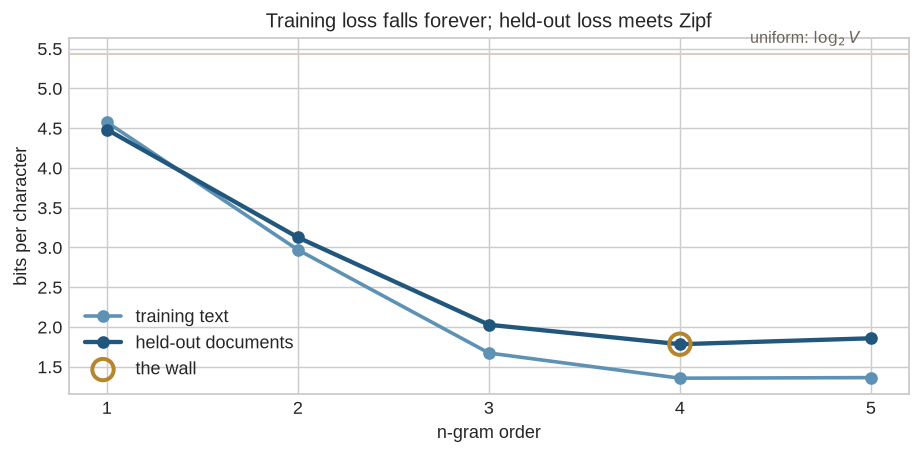

In [3]:
figure, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(orders, train_bits, 'o-', color=COLORS['blue_light'], lw=2, label='training text')
ax.plot(orders, heldout_bits, 'o-', color=COLORS['blue'], lw=2.4, label='held-out documents')
ax.axhline(math.log2(V), color=COLORS['grid'], lw=1.2)
ax.annotate('uniform: $\\log_2 V$', (orders[-1], math.log2(V)),
            textcoords='offset points', xytext=(-6, 6), ha='right',
            fontsize=9, color=COLORS['slate'])
wall = int(np.argmin(heldout_bits))
ax.scatter([orders[wall]], [heldout_bits[wall]], s=140, facecolor='none',
           edgecolor=COLORS['gold'], lw=2.2, zorder=5, label='the wall')
ax.set_xlabel('n-gram order'); ax.set_ylabel('bits per character')
ax.set_xticks(orders)
ax.set_title('Training loss falls forever; held-out loss meets Zipf', fontsize=11)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

The two curves are the whole of Session 1's Zipf argument in one picture:
lengthening the context always fits the *training* text better and, past the
wall, always predicts *held-out* text worse — because most long contexts have
been seen once or never, and a count table cannot share what it learned in
one context with any other. Each remaining rung removes exactly one defect
of this table.

## 3. Rung 2 — interpolation: the classical repair

Before neural networks, the fix was to *mix* orders,
$\hat p = \sum_n \lambda_n\, \hat p_n$, with the weights tuned on data
the counts never saw. This is the ancestor of everything Session 1 calls
smoothing; Kneser–Ney is a refined relative. It buys a real improvement —
and it still cannot share strength *across* contexts.

In [4]:
dev_cut = max(1, len(train_documents) // 5)
tune_documents, dev_documents = train_documents[dev_cut:], train_documents[:dev_cut]
component_models = [fit_ngram(tune_documents, n) for n in orders]
PAD = max(orders) - 1

def component_probabilities(documents_):
    rows = []
    for document in documents_:
        ids = encode(document)
        padded = [char_to_id[' ']] * PAD + ids
        for t in range(len(ids)):
            context = padded[t:t + PAD]
            rows.append([m['prob'](context, ids[t]) for m in component_models])
    return np.array(rows)

# Mixture weights by EM -- expected counts, then normalise: the same
# count-and-normalise M-step the deck derives for Baum-Welch, because a
# lambda-mixture IS a one-step latent-variable model over "which order".
dev_probabilities = component_probabilities(dev_documents)
lambdas = np.full(len(component_models), 1 / len(component_models))
for _ in range(40):
    weighted = dev_probabilities * lambdas
    responsibilities = weighted / weighted.sum(axis=1, keepdims=True)
    lambdas = responsibilities.mean(axis=0)

heldout_probabilities = component_probabilities(heldout_documents)
interpolated_heldout = float(-np.log2(heldout_probabilities @ lambdas).mean())
single_on_tune = [float(-np.log2(heldout_probabilities[:, i]).mean())
                  for i in range(len(component_models))]
ladder_rows.append(('interpolated 1-5 (EM)', interpolated_heldout))
print('lambda by EM:', ', '.join(f'n={n}: {l:.2f}' for n, l in zip(orders, lambdas)))
print(f'held-out: {interpolated_heldout:.3f} bits/char; the best single order '
      f'fitted on the same data gives {min(single_on_tune):.3f} -- the mixture '
      f'can only match or beat its own components')
assert interpolated_heldout <= min(single_on_tune) + 0.02

lambda by EM: n=1: 0.00, n=2: 0.06, n=3: 0.34, n=4: 0.40, n=5: 0.20
held-out: 1.898 bits/char; the best single order fitted on the same data gives 1.910 -- the mixture can only match or beat its own components


## 4. The head that never changes: $\partial \ell / \partial z = p - e_y$

Every rung above this line is *trained*, and everything trains through one
gradient. For logits $z$, probabilities $p = \mathrm{softmax}(z)$ and loss
$\ell = -\log p_y$, Session 1 derived
$$\frac{\partial \ell}{\partial z} = p - e_y .$$
Do not take the deck's word for it. Below, a softmax bigram — logits
$z = W\,\mathrm{onehot}(x_{t-1})$ — is differentiated twice: once with the
formula, once numerically. The check must agree to ~$10^{-8}$; it is the
same check `verify-claims/derive.py` runs on every push.

In [5]:
W = rng.normal(0, 0.1, size=(V, V))
ids = encode(train_text[:400])
pairs = [(a, b) for a, b in zip(ids[:-1], ids[1:])]

def loss_and_analytic_gradient(W_):
    gradient, total = np.zeros_like(W_), 0.0
    for previous, current in pairs:
        z = W_[:, previous]
        z = z - z.max()
        p = np.exp(z) / np.exp(z).sum()
        total -= math.log(max(p[current], 1e-300))
        g = p.copy(); g[current] -= 1.0        # p - e_y, the whole story
        gradient[:, previous] += g
    return total / len(pairs), gradient / len(pairs)

loss0, analytic = loss_and_analytic_gradient(W)
epsilon, checked, worst = 1e-5, 0, 0.0
for _ in range(25):
    i, j = rng.integers(V), rng.integers(V)
    W[i, j] += epsilon; up, _ = loss_and_analytic_gradient(W)
    W[i, j] -= 2 * epsilon; down, _ = loss_and_analytic_gradient(W)
    W[i, j] += epsilon
    numeric = (up - down) / (2 * epsilon)
    worst = max(worst, abs(numeric - analytic[i, j])); checked += 1
print(f'{checked} coordinates checked; max |numeric - (p - e_y)| = {worst:.2e}')
assert worst < 1e-6
print('The gradient of the head is p - e_y. It will not change again in this notebook.')

25 coordinates checked; max |numeric - (p - e_y)| = 7.58e-11
The gradient of the head is p - e_y. It will not change again in this notebook.


## 5. Rung 3 — distributed representations (a character-level Bengio model)

**Defect removed:** the count table treats every context as an island. Give
each character a learned vector and contexts that *look* alike now *share*
parameters — strength flows across contexts through the embedding space.
The head, the loss, and the gradient are unchanged; only the encoder
(a one-hidden-layer MLP over the last 8 characters) is new.

In [6]:
if TORCH_OK:
    import torch.nn as tnn
    CONTEXT, EMBED, HIDDEN = 8, 24, 128
    BOS = char_to_id[' ']

    def make_examples(documents_):
        xs, ys = [], []
        for document in documents_:
            ids_ = encode(document)
            padded = [BOS] * CONTEXT + ids_
            for t in range(len(ids_)):
                xs.append(padded[t:t + CONTEXT]); ys.append(ids_[t])
        return torch.tensor(xs), torch.tensor(ys)

    train_x, train_y = make_examples(tune_documents)
    dev_x, dev_y = make_examples(dev_documents)
    heldout_x, heldout_y = make_examples(heldout_documents)

    mlp = tnn.Sequential(
        tnn.Embedding(V, EMBED), tnn.Flatten(),
        tnn.Linear(CONTEXT * EMBED, HIDDEN), tnn.Tanh(),
        tnn.Linear(HIDDEN, V),
    )
    optimiser = torch.optim.AdamW(mlp.parameters(), lr=3e-3, weight_decay=1e-4)
    loss_fn = tnn.CrossEntropyLoss()
    best_state, best_dev = None, float('inf')
    for step in range(400):
        batch = torch.randint(0, len(train_x), (128,))
        optimiser.zero_grad()
        loss = loss_fn(mlp(train_x[batch]), train_y[batch])
        loss.backward(); optimiser.step()
        if step % 25 == 0:
            with torch.no_grad():
                dev_bits = loss_fn(mlp(dev_x), dev_y).item() / math.log(2)
            if dev_bits < best_dev:
                best_dev = dev_bits
                best_state = {k: v.clone() for k, v in mlp.state_dict().items()}
    mlp.load_state_dict(best_state)
    with torch.no_grad():
        mlp_heldout = loss_fn(mlp(heldout_x), heldout_y).item() / math.log(2)
    parameters = sum(p.numel() for p in mlp.parameters())
    ladder_rows.append(('char MLP (Bengio)', float(mlp_heldout)))
    print(f'{parameters:,} parameters; early-stopped on dev at {best_dev:.3f}; '
          f'held-out {mlp_heldout:.3f} bits/char')
    delta = min(heldout_bits) - mlp_heldout
    print(f'versus the best count table: {delta:+.3f} bits/char -- '
          + ('sharing across contexts pays even at this size.' if delta > 0 else
             'data-starved: the rung removes a defect, but the payoff needs corpus '
             '(Session 2).'))
    print('Ten held-out documents make a noisy judge either way: rerun with a '
          'different seed before concluding anything.')
else:
    print('Skipped: PyTorch unavailable.')

31,283 parameters; early-stopped on dev at 2.163; held-out 1.169 bits/char
versus the best count table: +0.613 bits/char -- sharing across contexts pays even at this size.
Ten held-out documents make a noisy judge either way: rerun with a different seed before concluding anything.


## 6. Rung 4 — attention: content-based mixing (a two-layer transformer)

**Defect removed:** the MLP mixes its context by *position* — the vector for
"8 characters ago" is combined the same way whatever those characters are.
Attention lets each position choose what to read *by content*, at every
step, in parallel. Same head, same loss, same $p - e_y$; the encoder is now
two pre-norm transformer blocks with causal masking — Session 1's final rung
in about forty lines.

In [7]:
if TORCH_OK:
    import torch.nn.functional as F

    class Block(tnn.Module):
        def __init__(self, d, heads):
            super().__init__()
            self.ln1, self.ln2 = tnn.LayerNorm(d), tnn.LayerNorm(d)
            self.attention = tnn.MultiheadAttention(d, heads, batch_first=True)
            self.mlp = tnn.Sequential(tnn.Linear(d, 4 * d), tnn.GELU(), tnn.Linear(4 * d, d))
        def forward(self, h, mask):
            a, _ = self.attention(self.ln1(h), self.ln1(h), self.ln1(h),
                                  attn_mask=mask, need_weights=False)
            h = h + a
            return h + self.mlp(self.ln2(h))

    class TinyTransformer(tnn.Module):
        def __init__(self, V_, d=64, heads=4, layers=2, context=64):
            super().__init__()
            self.context = context
            self.token = tnn.Embedding(V_, d)
            self.position = tnn.Embedding(context, d)
            self.blocks = tnn.ModuleList(Block(d, heads) for _ in range(layers))
            self.out = tnn.Linear(d, V_)
        def forward(self, idx):
            T = idx.shape[1]
            mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
            h = self.token(idx) + self.position(torch.arange(T))
            for block in self.blocks:
                h = block(h, mask)
            return self.out(h)

    def sample_windows(text_ids, count, width):
        assert len(text_ids) > width + 1, 'corpus too small for this context width'
        starts = torch.randint(0, len(text_ids) - width - 1, (count,))
        x = torch.stack([torch.tensor(text_ids[int(s):int(s) + width]) for s in starts])
        y = torch.stack([torch.tensor(text_ids[int(s) + 1:int(s) + width + 1]) for s in starts])
        return x, y

    tune_ids = encode(' '.join(tune_documents))
    dev_ids = encode(' '.join(dev_documents))
    heldout_ids = encode(' '.join(heldout_documents))

    def full_pass_bits(model, text_ids, width=64):
        # every position exactly once: deterministic, comparable to the tables
        total, count = 0.0, 0
        with torch.no_grad():
            for start in range(0, len(text_ids) - 1, width):
                window = torch.tensor(text_ids[start:start + width + 1]).unsqueeze(0)
                if window.shape[1] < 2: break
                logits = model(window[:, :-1])
                nll = F.cross_entropy(logits.transpose(1, 2), window[:, 1:],
                                      reduction='sum')
                total += nll.item(); count += window.shape[1] - 1
        return total / count / math.log(2)

    tiny = TinyTransformer(V)
    optimiser = torch.optim.AdamW(tiny.parameters(), lr=1e-3, weight_decay=1e-2)
    best_state, best_dev = None, float('inf')
    for step in range(600):
        x, y = sample_windows(tune_ids, 48, 64)
        optimiser.zero_grad()
        loss = F.cross_entropy(tiny(x).transpose(1, 2), y)
        loss.backward(); optimiser.step()
        if step % 30 == 0:
            dev_bits = full_pass_bits(tiny, dev_ids)
            if dev_bits < best_dev:
                best_dev = dev_bits
                best_state = {k: v.clone() for k, v in tiny.state_dict().items()}
    tiny.load_state_dict(best_state)
    tiny_heldout = full_pass_bits(tiny, heldout_ids)
    parameters = sum(p.numel() for p in tiny.parameters())
    ladder_rows.append(('2-layer transformer', float(tiny_heldout)))
    print(f'{parameters:,} parameters; held-out {tiny_heldout:.3f} bits/char '
          f'(every held-out position scored once)')
    delta = min(heldout_bits) - tiny_heldout
    print(f'versus the best count table: {delta:+.3f} bits/char. At 3k training '
          'characters a 100k-parameter attention model is fighting above the '
          'data it has -- hold that thought for the stretch path.')
else:
    print('Skipped: PyTorch unavailable.')

109,611 parameters; held-out 1.944 bits/char (every held-out position scored once)
versus the best count table: -0.162 bits/char. At 3k training characters a 100k-parameter attention model is fighting above the data it has -- hold that thought for the stretch path.


At this corpus size the ordering can be tight or even inverted: that is a finding, not a failure. Rerun after the stretch path fetches a real filing and watch the neural rungs separate.


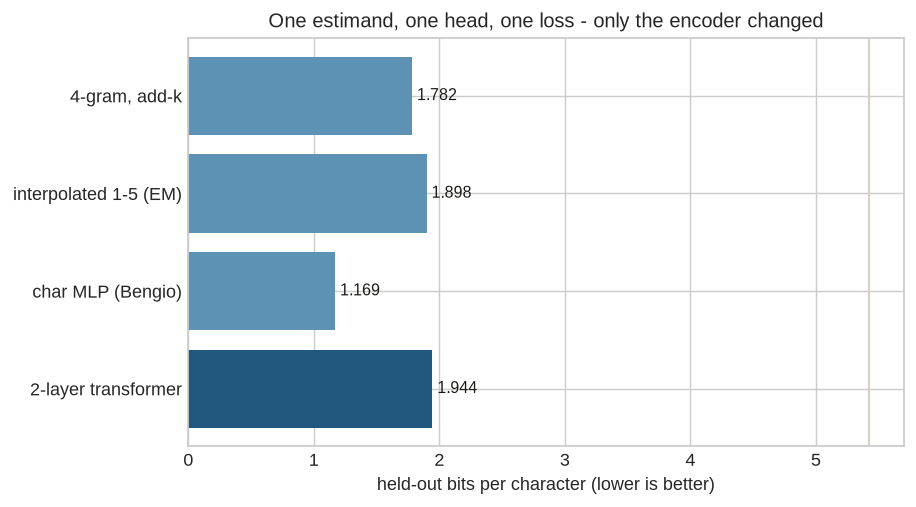

In [8]:
labels = [name for name, _ in ladder_rows]
values = [bits for _, bits in ladder_rows]
figure, ax = plt.subplots(figsize=(7.2, 0.65 * len(ladder_rows) + 1.4))
bars = ax.barh(range(len(values))[::-1], values,
               color=[COLORS['blue_light']] * (len(values) - 1) + [COLORS['blue']])
ax.set_yticks(range(len(values))[::-1]); ax.set_yticklabels(labels)
ax.axvline(math.log2(V), color=COLORS['grid'], lw=1.2)
for y, v in zip(range(len(values))[::-1], values):
    ax.text(v + 0.04, y, f'{v:.3f}', va='center', fontsize=9, color=COLORS['ink'])
ax.set_xlabel('held-out bits per character (lower is better)')
ax.set_title('One estimand, one head, one loss - only the encoder changed',
             fontsize=11)
plt.tight_layout(); plt.show()
print('At this corpus size the ordering can be tight or even inverted: '
      'that is a finding, not a failure. Rerun after the stretch path '
      'fetches a real filing and watch the neural rungs separate.')

## 7. Deep path — the induction bump, measured in a trained GPT-2

Session 1 asserted that two attention heads compose into an *in-context
bigram*: match the current token against the past, copy what followed it
last time. Here is the measurement. Feed GPT-2 a sequence of **random**
tokens repeated twice. On the first pass nothing is predictable; on the
second pass, a model with induction heads should be *dramatically* better —
not because it knows the tokens, but because it can look them up in its own
context.

**Predict before running:** where exactly in the position axis should loss
fall — at the repeat boundary, or one token after it? And what should a
*randomly initialised* GPT-2 (same architecture, no training) do?

In [9]:
if RUN_HUGGINGFACE:
    import torch
    from transformers import GPT2Config, GPT2LMHeadModel
    import torch.nn.functional as F

    PERIOD, BATCH = 50, 8
    token_ids = torch.randint(1000, 10000, (BATCH, PERIOD))
    sequence = torch.cat([token_ids, token_ids], dim=1)      # length 2*PERIOD

    def per_position_nll(model):
        model.eval()
        with torch.no_grad():
            logits = model(sequence).logits
        nll = F.cross_entropy(
            logits[:, :-1].reshape(-1, logits.shape[-1]),
            sequence[:, 1:].reshape(-1), reduction='none',
        ).reshape(BATCH, -1)
        return nll.mean(dim=0).numpy()

    trained = GPT2LMHeadModel.from_pretrained('gpt2', attn_implementation='eager')
    control = GPT2LMHeadModel(GPT2Config())         # same shape, never trained
    nll_trained, nll_control = per_position_nll(trained), per_position_nll(control)

    figure, ax = plt.subplots(figsize=(7.6, 3.6))
    positions = np.arange(1, 2 * PERIOD)
    ax.plot(positions, nll_control, color=COLORS['grid'], lw=1.6,
            label='random init (control)')
    ax.plot(positions, nll_trained, color=COLORS['blue'], lw=2.2,
            label='trained GPT-2')
    ax.axvline(PERIOD, color=COLORS['gold'], lw=1.5, linestyle='--')
    ax.annotate('repeat begins', (PERIOD, ax.get_ylim()[1] * 0.93),
                textcoords='offset points', xytext=(6, 0), fontsize=9,
                color=COLORS['gold'])
    ax.set_xlabel('position'); ax.set_ylabel('NLL (nats)')
    ax.set_title('The induction bump: loss collapses on the second pass',
                 fontsize=11)
    ax.legend(frameon=False)
    plt.tight_layout(); plt.show()
    first, second = nll_trained[:PERIOD - 1].mean(), nll_trained[PERIOD:].mean()
    print(f'trained GPT-2: first pass {first:.2f} nats -> second pass {second:.2f}')
    print(f'random control: {nll_control[:PERIOD - 1].mean():.2f} -> '
          f'{nll_control[PERIOD:].mean():.2f} (no look-up circuit, no bump)')
else:
    print('Set RUN_HUGGINGFACE=True to download GPT-2 (~0.5 GB) and run this cell.')

Set RUN_HUGGINGFACE=True to download GPT-2 (~0.5 GB) and run this cell.


### 7.1 Which heads do it? The prefix-matching score

In a sequence with period $T$, an induction head at position $t$ on the
second pass attends to position $t - T + 1$: *the token that followed the
previous occurrence of the current token*. Averaging each head's attention
weight at exactly that offset gives a per-head **prefix-matching score**.
Heads that light up are the mechanical substrate of in-context learning —
the reason Session 2 could read few-shot prompting as conditioning.

In [10]:
if RUN_HUGGINGFACE:
    with torch.no_grad():
        attentions = trained(sequence, output_attentions=True).attentions
    scores = np.zeros((len(attentions), attentions[0].shape[1]))
    query_positions = np.arange(PERIOD, 2 * PERIOD - 1)
    target_positions = query_positions - (PERIOD - 1)
    for layer, attention in enumerate(attentions):
        weights = attention.mean(dim=0).numpy()      # heads x query x key
        scores[layer] = weights[:, query_positions, target_positions].mean(axis=1)

    figure, ax = plt.subplots(figsize=(7.0, 4.6))
    image = ax.imshow(scores, cmap='Blues', aspect='auto', vmin=0)
    ax.set_xlabel('head'); ax.set_ylabel('layer')
    ax.set_title('Prefix-matching score: attention mass at offset $-(T-1)$',
                 fontsize=11)
    plt.colorbar(image, ax=ax, shrink=0.85)
    plt.tight_layout(); plt.show()
    best_heads = np.dstack(np.unravel_index(np.argsort(-scores, axis=None), scores.shape))[0][:3]
    for layer, head in best_heads:
        print(f'layer {layer:2d}, head {head:2d}: prefix-matching score {scores[layer, head]:.2f}')
    print('Compare with the induction-head frame of Session 1: matching plus '
          'copying, assembled from two layers -- here found, not asserted.')
else:
    print('Set RUN_HUGGINGFACE=True to compute the head-level scores.')

Set RUN_HUGGINGFACE=True to compute the head-level scores.


## 8. Stretch — a real corpus, and a miniature scaling fit

The frozen fallback kept every rung honest but data-starved. This cell
fetches **one full Microsoft 10-K** from official EDGAR (an identified
`SEC_USER_AGENT` Colab secret is required; no API key), strips the HTML,
saves `mdna_corpus.txt` next to the teaching CSVs, and reruns the ladder —
the same functions, two orders of magnitude more characters. Committed back
to the repository, the file becomes the offline fallback for next year.

In [11]:
if REFRESH_FROM_SEC:
    import requests, time, html as html_module
    try:
        from google.colab import userdata
        sec_user_agent = userdata.get('SEC_USER_AGENT')
    except Exception:
        sec_user_agent = None
    assert sec_user_agent, (
        'Add SEC_USER_AGENT to Colab secrets, e.g. '
        '"University of Zurich your.email@uzh.ch".'
    )
    filing_url = ('https://www.sec.gov/Archives/edgar/data/789019/'
                  '000095017024087843/msft-20240630.htm')
    headers = {'User-Agent': sec_user_agent, 'Accept-Encoding': 'gzip, deflate'}
    response = requests.get(filing_url, headers=headers, timeout=60)
    response.raise_for_status(); time.sleep(0.12)
    page = html_module.unescape(response.text)
    page = re.sub(r'(?is)<(script|style)[^>]*>.*?</\1>', ' ', page)
    text = re.sub(r'(?s)<[^>]+>', ' ', page)
    text = re.sub(r'\s+', ' ', text)
    # keep the narrative core: from Item 7 (MD&A) to Item 8, when present
    match = re.search(r'(?i)item\s*7\.?\s*management', text)
    if match: text = text[match.start():]
    match = re.search(r'(?i)item\s*8\.?\s*financial statements', text)
    if match: text = text[:match.start()]
    output_path = next((p.parent for p in [Path('../teaching-data/x'),
                                           Path('teaching-data/x')]
                        if p.parent.exists()), Path('.')) / 'mdna_corpus.txt'
    output_path.write_text(text.lower())
    print(f'Saved {len(text):,} characters to {output_path}.')
    print('Now RESTART AND RUN ALL: the setup cell will pick the file up '
          'and every rung above reruns on the real corpus.')
else:
    print('Frozen fast path active; no network request made.')

Frozen fast path active; no network request made.


### 8.1 A miniature scaling fit — the method, not the law

With the real corpus in place, train the tiny transformer at three widths
for a **fixed token budget** and fit $\log L = \alpha \log N + c$. Two honest
caveats before you believe anything: this sits *five decades* below the
published regimes, and Session 2 spent a morning on why fitted exponents are
conditional on architecture, tokenizer and corpus. The point is to own the
*procedure* — an isoFLOP-style comparison at fixed data — not to reproduce
a law.

In [12]:
if RUN_SCALING and TORCH_OK:
    assert corpus_file is not None, (
        'Fetch the corpus, then RESTART AND RUN ALL so the setup cell loads '
        'mdna_corpus.txt -- the fit is meaningless on the starved fallback.')
    results = []
    for width in (32, 64, 128):
        model = TinyTransformer(V, d=width, heads=4, layers=2)
        optimiser = torch.optim.AdamW(model.parameters(), lr=1e-3)
        for step in range(400):
            x, y = sample_windows(tune_ids, 32, 64)
            optimiser.zero_grad()
            F.cross_entropy(model(x).transpose(1, 2), y).backward()
            optimiser.step()
        with torch.no_grad():
            hx, hy = sample_windows(heldout_ids, 256, 64)
            bits = F.cross_entropy(model(hx).transpose(1, 2), hy).item() / math.log(2)
        parameters = sum(p.numel() for p in model.parameters())
        results.append((parameters, bits))
        print(f'd={width:>3}: {parameters:>9,} parameters -> {bits:.3f} bits/char')
    logN = np.log10([n for n, _ in results]); logL = np.log10([b for _, b in results])
    slope, intercept = np.polyfit(logN, logL, 1)
    figure, ax = plt.subplots(figsize=(6.4, 3.6))
    ax.plot(logN, logL, 'o', color=COLORS['blue'], ms=7)
    ax.plot(logN, slope * logN + intercept, '-', color=COLORS['gold'], lw=1.8,
            label=f'fitted slope {slope:.2f}')
    ax.set_xlabel('$\\log_{10}$ parameters'); ax.set_ylabel('$\\log_{10}$ bits/char')
    ax.set_title('Three points do not make a law - they make a method', fontsize=11)
    ax.legend(frameon=False)
    plt.tight_layout(); plt.show()
    print('Interrogate the fit the way Session 2 interrogated Chinchilla: '
          'how would the slope move with a different token budget, context '
          'length, or corpus? If you cannot answer, do not extrapolate.')
else:
    print('Set RUN_SCALING=True (after the SEC fetch) to run the mini fit.')

Set RUN_SCALING=True (after the SEC fetch) to run the mini fit.


## 9. What you verified, and where it points

- **The wall is real and arrives on schedule** — training loss falls
  monotonically in $n$ while held-out loss turns, and the singleton share
  of contexts tells you why (Session 1, the Zipf frames).
- **One gradient trains everything** — $p - e_y$ verified numerically; the
  head never changed while the encoder climbed four rungs (Session 1's
  through-line).
- **In-context learning is a circuit, not a metaphor** — the induction bump
  appears in a trained GPT-2 and not in the random control, and
  prefix-matching scores locate the heads (Session 1's induction frame,
  Session 2's reading of few-shot prompting).
- **Data moves the numbers** — the same ladder tells a starved story at
  4,000 characters and a sharper one at 400,000 (Session 2's opening).

*Next:* Lab 1 opens FinBERT on real filing sentences; Lab 2 makes the
corpus a filtration; Lab 3 turns model outputs into econometrics.